<h1 style="text-align:center; color:#5C0D37; font-size:45px;">
  ✈️ <b>(Airways) Outlier Detection (IQR & Z-Score)</b> 
</h1>

***Using statistical techniques to find extreme values.***


## <b>Importing Libraries<b>


In [1]:
# Data Manupilation
import pandas as pd
import numpy as np

# Data visulization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

--- 

# <b> Detecting and Handling Outliers </b>

---

In [47]:
# laod the refined dataset

cleaned_data_3 = pd.read_csv('AirlinePassengerSatisfaction_Cleaned.csv')

In [48]:
cleaned_data_3.sample(3)

,Customer ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
98231,74324,Male,Loyal Customer,59,Business travel,Business,2957,3,3,3,...,5,5,5,5,5,5,4,0,0.0,1
34864,127598,Female,disloyal Customer,36,Business travel,Eco,1773,3,3,3,...,2,1,1,4,4,4,2,0,0.0,0
128970,118268,Male,Loyal Customer,30,Business travel,Business,2926,4,5,5,...,4,4,5,4,4,4,4,0,0.0,0


* ***Detecting outliers of numeric columns through z-score method and IQR method, both handles only Numneric values***

In [49]:
numeric_cols = cleaned_data_3.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Customer ID', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


# ***IQR Method using boxplots***

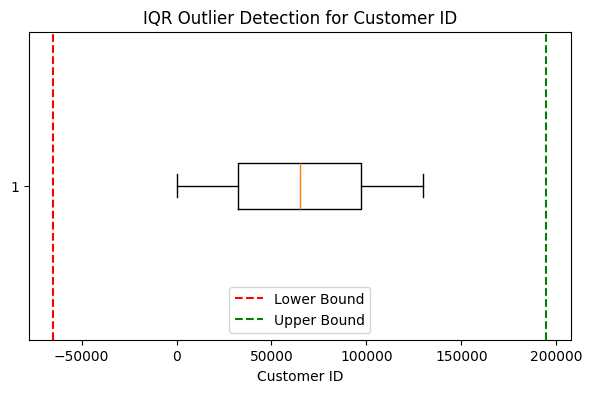

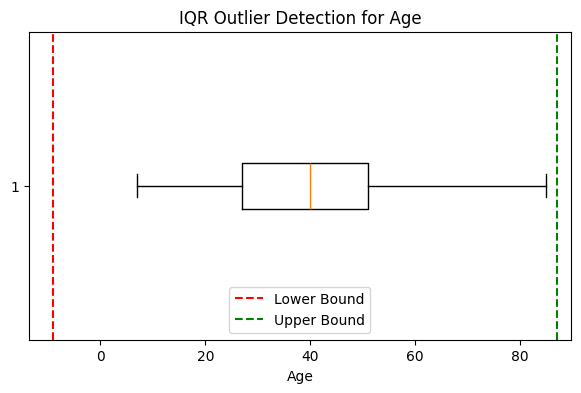

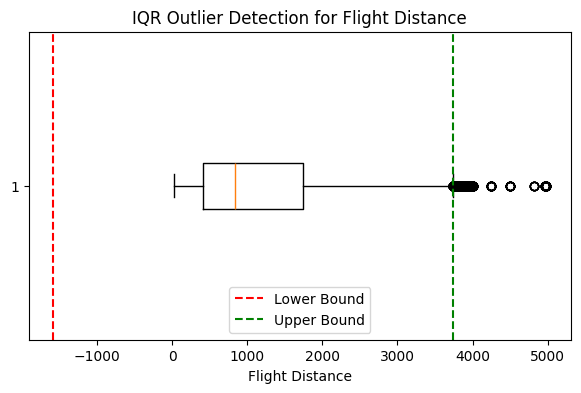

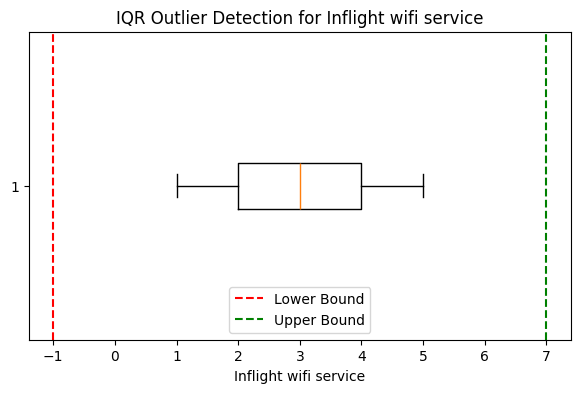

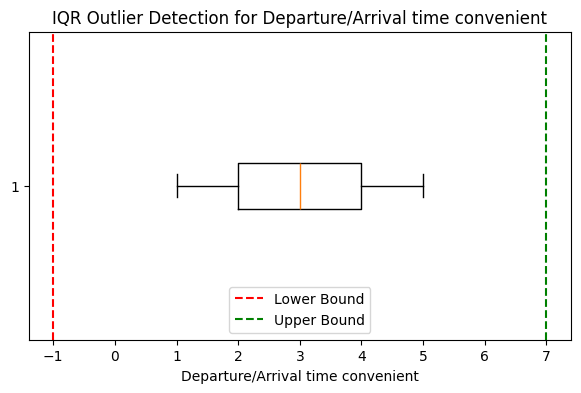

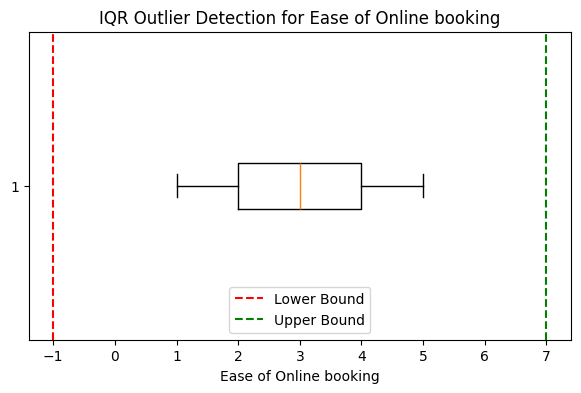

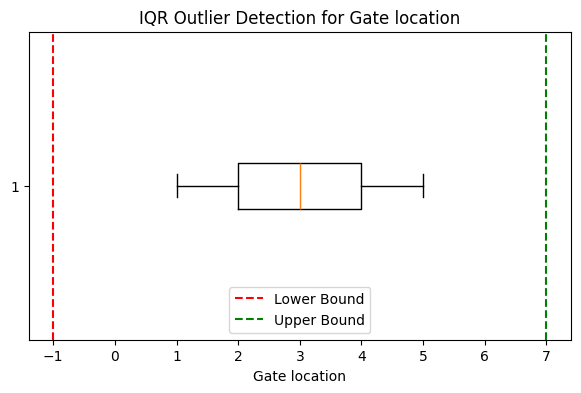

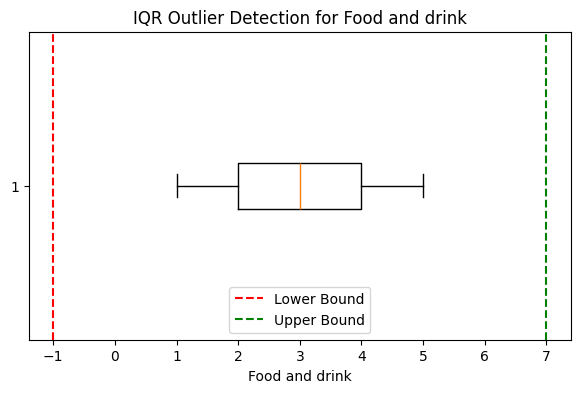

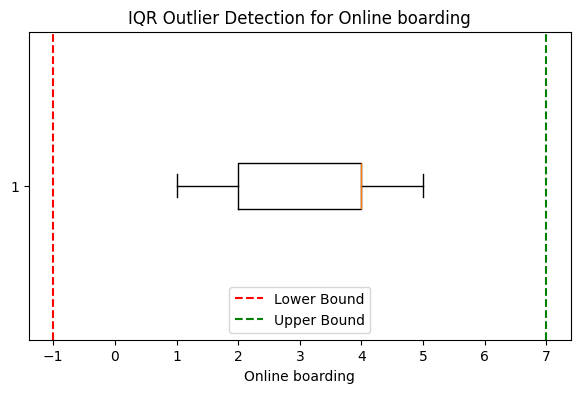

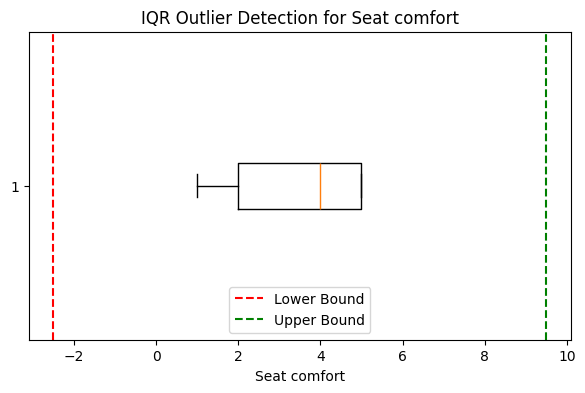

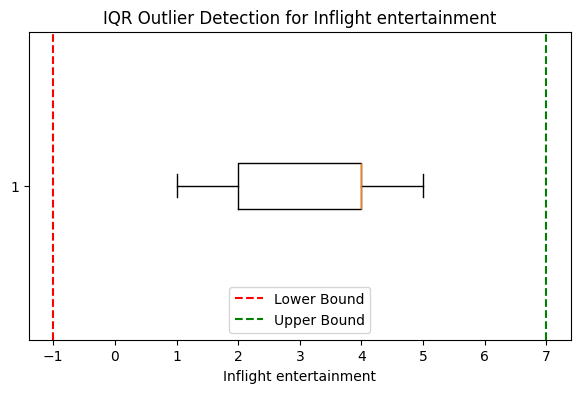

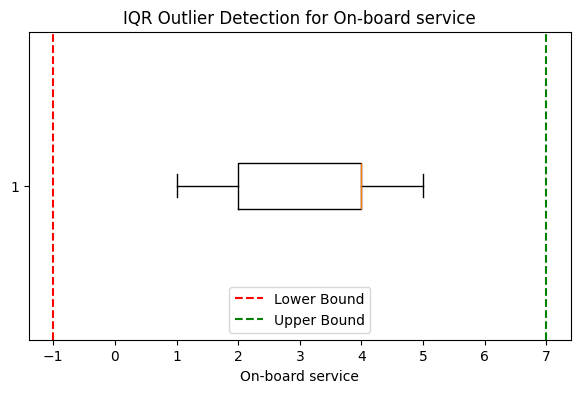

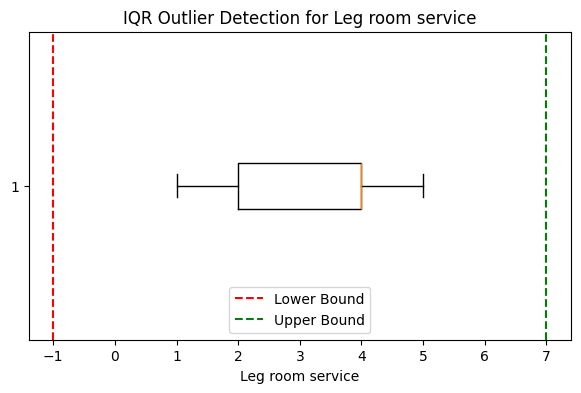

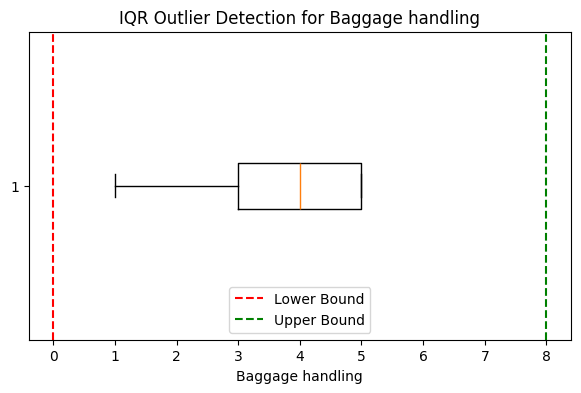

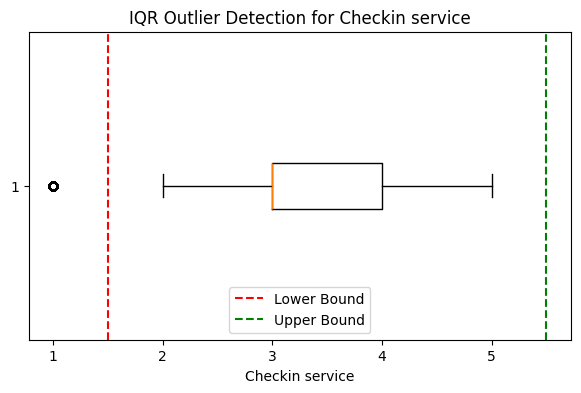

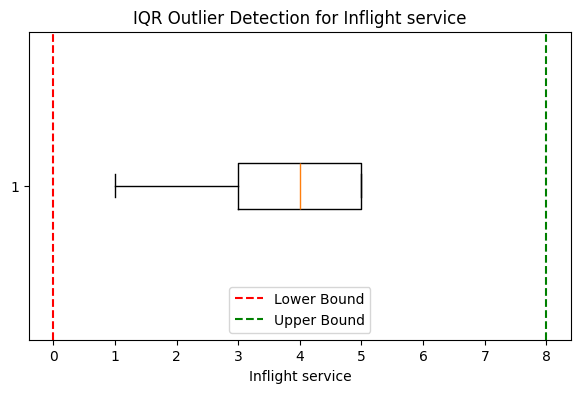

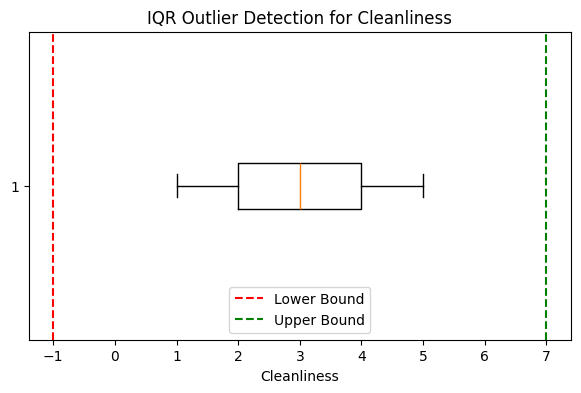

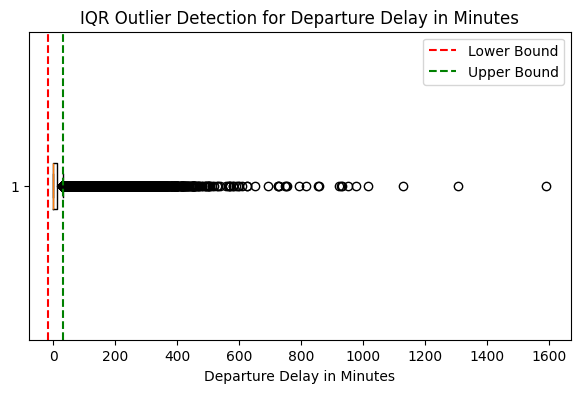

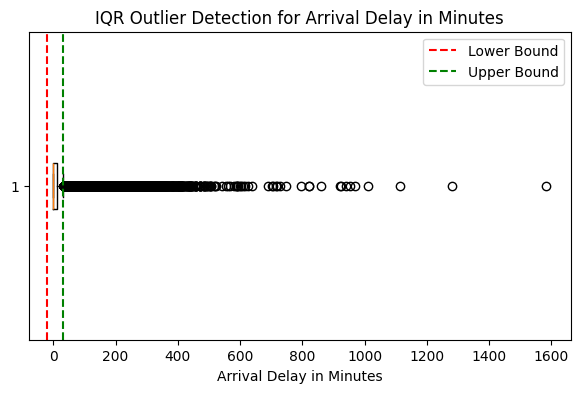

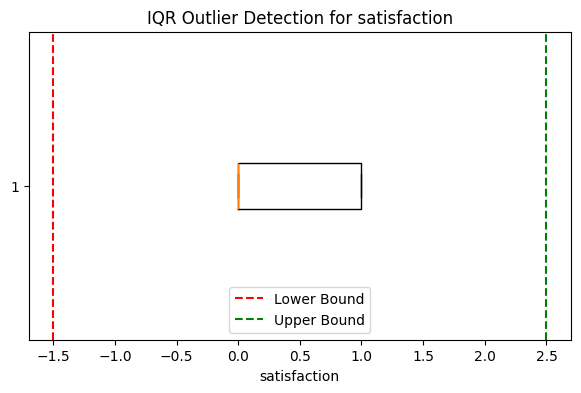

In [50]:

for col in numeric_cols:
    Q1 = cleaned_data_3[col].quantile(0.25)
    Q3 = cleaned_data_3[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    plt.figure(figsize=(7,4))
    plt.boxplot(cleaned_data_3[col].dropna(), vert=False)
    plt.title(f"IQR Outlier Detection for {col}")
    plt.xlabel(col)

    plt.axvline(lower, color="red", linestyle="--", label="Lower Bound")
    plt.axvline(upper, color="green", linestyle="--", label="Upper Bound")
    plt.legend()
    plt.show()


# <b>Analyzing Outliers</b>
* According to boxplot 3 columns having outlier, Filght distance, Departure delay, Arrival delay in Min
---

#### ***Flight Distance — Outlier Analysis***
---

***Why outliers appear?***

Some flights are very short (100–300 km)

Some are very long (2000–5000+ km)

Long flights naturally look like outliers, but they are valid values

***Should you remove them?***

NO, NEVER remove flight distance outliers, because some flights are `short distance` while some are `long distanace` they are all valid data points. Removing outliers in flight distance could lead to `loss of important information`...

---
#### ***Arrival Delay in Minutes — Outliers***
---

is outlier real? may be or not ..

thinkingg...........

yessss it may be true ..

How?

***Short Distance + Very Large Delay → TRUE Outlier***

**Example:**

Distance = 200 km

Arrival Delay = 1400 minutes (~23 hours)

This is unrealistic ---→ must be treated as an outlier.

***Real-World Rule***

Short-distance flights that have extremely `high arrival delays` are `true outliers` and should be `removed` or `handled separately`.

This is widely used in airline analytics, fraud detection, operational delay modeling, and ML pipelines.

In [51]:
cleaned_data_3.head()

,Customer ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


* ***Viz through scatter and IQRS***

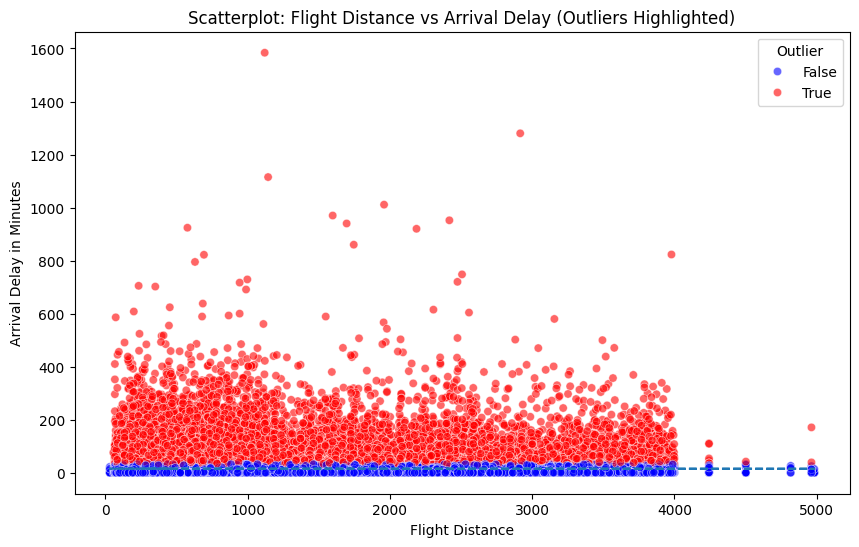

In [52]:
x = "Flight Distance"
y = "Arrival Delay in Minutes"

# --- Compute IQR for Arrival Delay ---
Q1 = cleaned_data_3[y].quantile(0.25)
Q3 = cleaned_data_3[y].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers (temporary Boolean mask)
outlier_mask = (cleaned_data_3[y] < lower) | (cleaned_data_3[y] > upper)

# --- Scatter Plot without modifying original dataset ---
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cleaned_data_3,
    x=x, y=y,
    hue=outlier_mask,
    palette={False:"blue", True:"red"},
    alpha=0.6
)

# Title & labels
plt.title("Scatterplot: Flight Distance vs Arrival Delay (Outliers Highlighted)")
plt.xlabel("Flight Distance")
plt.ylabel("Arrival Delay in Minutes")
plt.legend(title="Outlier")

# Trendline
z = np.polyfit(cleaned_data_3[x], cleaned_data_3[y], 1)
p = np.poly1d(z)
plt.plot(cleaned_data_3[x], p(cleaned_data_3[x]), linestyle="dashed")

plt.show()


🔵 Blue Dots → Normal Flights

These follow the general pattern between distance and delay.

🔴 Red Dots → Outliers

These points are above the IQR upper limit or below the lower limit.
They represent extremely high arrival delays (e.g., 500–1500 minutes).

---
# **✈ To Handling Outliers using Flight Distance vs Arrival Delay**

### **Why we use this method?**
Arrival delay is naturally related to flight distance:

- Long flights can have larger delays.(logically True)
- Short flights with very high delays are extremely rare and often caused by data errors.

Therefore, we detect outliers by combining **distance** and **arrival delay**.

---

### **Industry Logic:**
- A flight with **distance < 500 km** should not have **> 300 minutes delay**.
- Such cases are considered *true operational anomalies or data errors*.

*Examples of bad/outlier cases:*
- 200 km flight with 1200 min delay
- 350 km flight with 900 min delay

These are unrealistic and should be **separated**.

---


In [53]:
cleaned_data_3.sample(3)

,Customer ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80648,34990,Male,Loyal Customer,57,Business travel,Business,3722,3,3,1,...,5,5,4,5,4,5,4,0,0.0,1
70946,116079,Female,Loyal Customer,63,Personal Travel,Eco,480,4,3,4,...,2,2,4,4,2,2,4,11,11.0,0
38477,96163,Female,Loyal Customer,26,Business travel,Business,546,2,2,2,...,4,3,3,4,4,5,4,0,0.0,1


In [54]:
# flights less than 500 km
short_flights = cleaned_data_3["Flight Distance"] < 500

# Very high arrival delays
high_delay = cleaned_data_3["Arrival Delay in Minutes"] > 300

# Step 3: Combined true outliers
cleaned_data_3["True_Outlier"] = short_flights & high_delay

cleaned_data_3["True_Outlier"].value_counts()


True_Outlier
False    129801
True         79
Name: count, dtype: int64

In [55]:
# Seperate the bad outliers

separated_outliers = cleaned_data_3[cleaned_data_3["True_Outlier"] == True]

In [61]:
# Export outliers data into csv

separated_outliers.to_csv("airways_outliers.csv", index=False)

In [62]:
# Keep the clean data

cleaned_data_no_outliers = cleaned_data_3[cleaned_data_3["True_Outlier"] == False]

In [63]:
# Export the cleaned data without true outliers into csv

cleaned_data_no_outliers.to_csv("model_ready_flights.csv", index=False)

#### ***Now we can see that the cleaned_data_no_outliers dataframe contains only the data points that are not considered true outliers based on our defined criteria.***

#### ***here is the graphical representation of the cleaned data without outliers:***

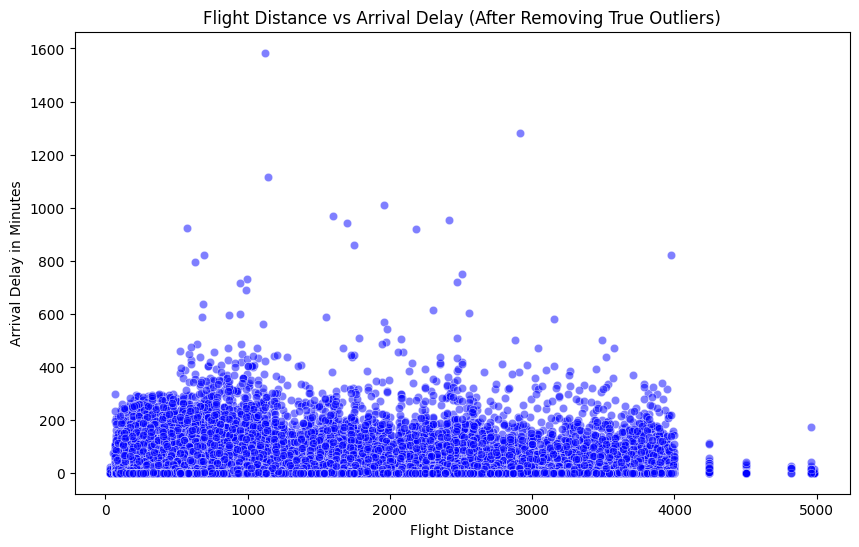

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cleaned_data_no_outliers,
    x="Flight Distance",
    y="Arrival Delay in Minutes",
    color="blue",
    alpha=0.5
)

plt.title("Flight Distance vs Arrival Delay (After Removing True Outliers)")
plt.xlabel("Flight Distance")
plt.ylabel("Arrival Delay in Minutes")
plt.show()
